## B1. Research Question
In a telecommunications company, customer retention and revenue stability are critical due to high churn rates and the high cost of acquiring new customers. Since revenue fluctuates over time, understanding its temporal behavior is essential for forecasting and strategic planning.

### Research Question:
How can historical daily revenue patterns be used to forecast future revenue trends in order to support customer retention and financial planning strategies in a telecommunications company?

This question is relevant because revenue is directly influenced by customer churn behavior, and forecasting it enables the organization to anticipate revenue drops and proactively adjust retention strategies.


---
## B2. Objectives of the Data Analysis
The primary goals of this time series analysis are:

**1.	Identify underlying patterns in revenue over time.**
Detect trends, seasonality, and cyclical behavior in daily revenue data across the first two years of operation. 

**2.	Develop a forecasting model for future revenue.**
Use time series modeling (specifically ARIMA-based methods) to predict future revenue values based on historical patterns. 

**3.	Evaluate revenue stability and volatility.**
Quantify how stable or volatile revenue is over time to understand operational risk and customer churn impact. 

**4.	Support business decision-making.**
Provide forecasts that can help executives plan retention strategies, staffing, and financial resource allocation. 

**5.	Assess predictability of revenue behavior.**
Determine whether revenue follows statistically reliable patterns (stationarity and autocorrelation structure) suitable for time series modeling. 

All objectives are feasible given the dataset, which contains 731 sequential daily revenue observations.


---
### C. Assumptions of a Time Series Model

Time series modeling relies on several key statistical assumptions to ensure valid forecasting results.

### 1. Stationarity
A core assumption is that the time series is stationary or can be transformed into a stationary series.

A stationary time series has:

- Constant mean over time 
- Constant variance 
- Stable autocovariance structure (depends only on lag, not time) 

Why it matters:
- ARIMA models assume stationarity in the underlying data (or stationarity after differencing). 
- If trends or seasonality exist, transformations (e.g., differencing or decomposition) are required. 


### 2. Autocorrelation (Temporal Dependence)

Time series data assumes observations are not independent.

Instead:
- Current values are influenced by past values 
- This relationship is captured using autocorrelation 

Key concepts:
- **Autocorrelation Function (ACF):** measures correlation between a series and its lagged values 
- **Partial Autocorrelation Function (PACF):** measures direct relationship between observations at specific lags 

Why it matters:
- ARIMA models explicitly rely on autocorrelation structure to build AR (autoregressive) and MA (moving average) components. 


### 3. Error Independence

Model residuals (errors) should:

- Be randomly distributed 
- Show no autocorrelation 
- Resemble white noise 

If residuals still contain structure, the model is inadequate.


### 4. Linearity (for ARIMA family models)

ARIMA assumes that:

- The relationship between lagged values and current values is linear 
Non-linear patterns may require more advanced models (e.g., LSTM, nonlinear state space models).

### 5. Homoscedasticity (Constant Variance)

The variance of the series should remain stable over time:
- No increasing/decreasing volatility patterns 
If violated, transformations like log scaling may be required.

### 6. Sufficient Temporal Ordering

Time series data must:
- Be ordered chronologically 
- Have consistent time intervals (daily in this dataset: 731 days) 




---
## D1. Visualization of the Time Series

To understand the overall behavior of the dataset, a line graph was generated to visualize daily revenue over time. This helps identify trends, seasonality, and fluctuations in the data.

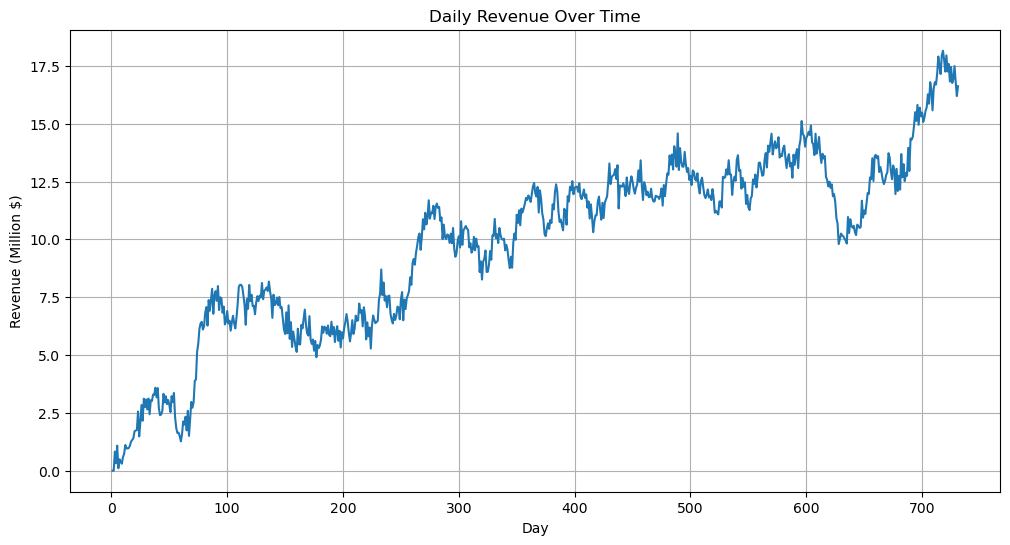

Dataset Preview: 

    Day   Revenue
0    1  0.000000
1    2  0.000793
2    3  0.825542
3    4  0.320332
4    5  1.082554 

...
     Day    Revenue
726  727  16.931559
727  728  17.490666
728  729  16.803638
729  730  16.194813
730  731  16.620798 



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data/churn_clean.csv")

# Plot
plt.figure(figsize=(12,6))
plt.plot(df['Day'], df['Revenue'])
plt.title("Daily Revenue Over Time")
plt.xlabel("Day")
plt.ylabel("Revenue (Million $)")
plt.grid()
plt.show()

# Preview
print("Dataset Preview: \n\n", df.head(), "\n")
print("...")
print(df.tail(), "\n")

### Visualization Observations

The time series exhibits a clear **upward trend**, with revenue increasing substantially over the observed period. Despite short-term fluctuations, the overall direction is consistently positive.

The series shows **frequent variability**, indicating short-term volatility; however, the magnitude of these fluctuations remains relatively stable, suggesting approximately constant variance.

The presence of a changing mean over time confirms that the series is **non-stationary**. This justifies the need for transformation, such as first-order differencing, prior to applying time series models.

---
## D2. Time Step Formatting

The dataset represents a univariate time series with daily observations. It is important to verify that the data is consistently spaced and free of missing values before applying time series models.

In [2]:
print("Dateset Info:  \n")
print("\n", df.info(), "\n")

Dateset Info:  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Day      731 non-null    int64  
 1   Revenue  731 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 11.5 KB

 None 



### Confirms:

- Columns (Day, Revenue)
- Data types
- No hidden nulls

In [3]:
# Check number of rows
print("Number of Rows: ", len(df))

# Check missing values
print("\nMissing value table: ")
print(df.isnull().sum())


Number of Rows:  731

Missing value table: 
Day        0
Revenue    0
dtype: int64


In [4]:
# Check if Days Are Sequential
df['Day_diff'] = df['Day'].diff()

print(df['Day_diff'].value_counts())

Day_diff
1.0    730
Name: count, dtype: int64


### Confirms: 

- Every step increases by exactly 1 day
- No missing days
- No duplicates

In [5]:
# Check for Duplicates

print(df.duplicated().sum())

0


In [6]:
# Check Ordering

df['Day'].is_monotonic_increasing

True

## Observations

The dataset represents a univariate time series consisting of daily revenue observations. Each data point corresponds to a sequential day, beginning at day 0 and continuing through day 730, resulting in a total of 731 observations.

The time steps are **evenly spaced at a daily frequency**, meaning that each observation occurs at a consistent one-day interval. This regular spacing is critical for time series modeling, as it ensures that temporal relationships between observations are preserved.

An assessment of the dataset shows that there are **no missing values or gaps in measurement**. Each day within the observed time frame is accounted for, and no irregular intervals or discontinuities are present in the sequence.

Overall, the dataset is **complete, continuous, and properly ordered**, making it well-suited for time series analysis without requiring additional preprocessing such as interpolation or resampling.

----
## D3. Stationarity Evaluation

Stationarity is a fundamental assumption in time series modeling. A stationary time series has a constant mean, constant variance, and an autocorrelation structure that does not change over time.

To evaluate stationarity, both **visual inspection** and a **statistical test (Augmented Dickey-Fuller test)** were used.

### ADF Test:

In [7]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df['Revenue'])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -1.9246121573101846
p-value: 0.32057281507939595
Critical Values:
   1%: -3.4393520240470554
   5%: -2.8655128165959236
   10%: -2.5688855736949163


The null hypothesis (H₀) of the ADF test states that the time series is non-stationary. Since the p-value (0.3206) is greater than the significance level of 0.05, the null hypothesis cannot be rejected.

Additionally, the ADF statistic (-1.9246) is not more negative than any of the critical values, further supporting the conclusion that the series is non-stationary.

This result aligns with the visual analysis, which showed an upward trend and a changing mean over time.

### Transformation to Achieve Stationarity

To address non-stationarity, first-order differencing was applied to the revenue series. This transformation removes trend components and stabilizes the mean of the series.

After differencing, the series is expected to become stationary and suitable for time series modeling techniques such as ARIMA.


### Transformation to Achieve Stationarity

To address non-stationarity, first-order differencing was applied to the revenue series:

$$
Y'_t = Y_t - Y_{t-1}
$$



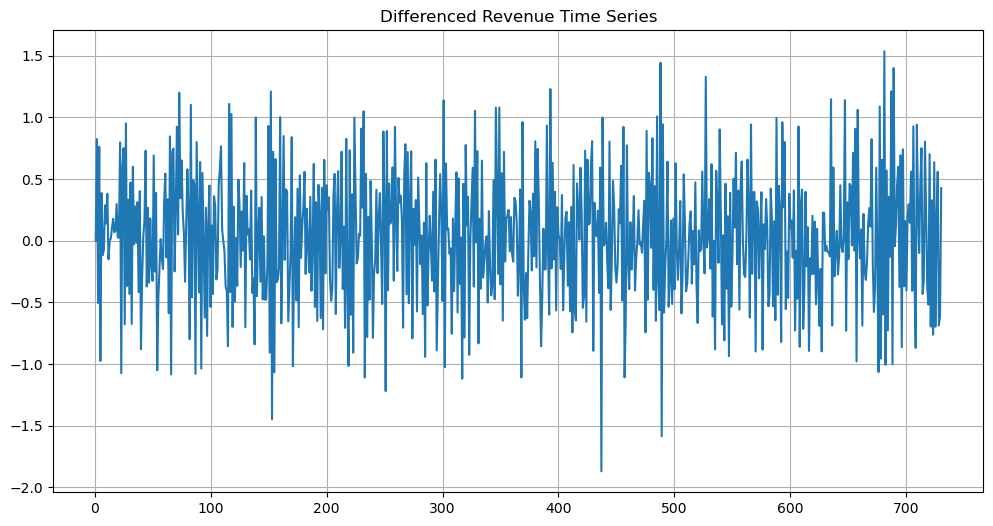

In [8]:
df['Revenue_diff'] = df['Revenue'].diff()
df_diff = df.copy()
df_diff = df_diff.dropna()

plt.figure(figsize=(12,6))
plt.plot(df_diff['Revenue_diff'])
plt.title("Differenced Revenue Time Series")
plt.grid()
plt.show()

### ADF Test on Differenced Data:

In [9]:
adf_diff = adfuller(df_diff['Revenue_diff'])

print("ADF Statistic (Differenced):", adf_diff[0])
print("p-value (Differenced):", adf_diff[1])

ADF Statistic (Differenced): -44.874527193876
p-value (Differenced): 0.0



After differencing, the p-value is significantly less than 0.05, leading to rejection of the null hypothesis. This indicates that the differenced series is stationary.

The extremely low p-value and highly negative ADF statistic suggest strong evidence of stationarity. This confirms that first-order differencing successfully removed the trend component and stabilized the mean of the series.

### Conclusion

The original time series is non-stationary, but becomes stationary after first-order differencing. Therefore, a differencing order of **d = 1** will be appropriate when building an ARIMA model.

---
## D4. Data Preparation

Several preprocessing steps were performed to prepare the dataset for time series analysis.

First, the dataset was inspected for **missing values, duplicates,** and **inconsistencies**. No missing values or duplicate records were found, and the data was confirmed to be complete and properly ordered by day.

Next, the stationarity of the series was evaluated using the Augmented Dickey-Fuller (ADF) test. Since the original series was found to be non-stationary, first-order differencing was applied to remove the trend component and stabilize the mean. The transformed series was then confirmed to be stationary using a second ADF test.

After preparing the data, the dataset was split into training and testing subsets. The first 80% of the observations were assigned to the training set, while the remaining 20% were reserved for the test set.

This split preserves the chronological order of the data, which is essential in time series analysis. The training set is used to build and fit the model, while the test set is used to evaluate the model’s forecasting performance on unseen data.

Overall, these steps ensure that the data is clean, properly structured, and suitable for time series modeling.

In [10]:
# Convert Day to datetime
df_diff['Day'] = pd.date_range(start='2020-01-01', periods=len(df_diff), freq='D')
df_diff = df_diff.set_index('Day')
df_diff = df_diff.asfreq('D')

### Datetime Index Justification

For ARIMA-based time series analysis in Python, it is recommended to use a supported datetime index format to enable proper temporal modeling and forecasting. The original dataset used a simple numerical index representing days (0–730), which is not an ideal temporal index structure for forecasting procedures in `statsmodels`.

To support time series analysis, the numerical index was converted into a daily datetime index beginning on **2020-01-01**. Although the original dataset does not specify actual calendar dates, assigning sequential dates provides a valid temporal structure required for model fitting and forecast generation.

This assumption does not affect the statistical properties, trends, or relationships within the data, as the analysis depends on the sequential ordering and spacing of observations rather than the specific calendar dates themselves.

### Cleaned Dataset Structure

The cleaned dataset consists of three columns in addition to the datetime index:

- **Revenue**: Contains the original revenue values from the dataset and represents the primary variable analyzed in the time series model.

- **Day_diff**: Represents the difference in time steps between consecutive observations. Since the dataset is evenly spaced with daily intervals, this column confirms consistent temporal spacing throughout the series.

- **Revenue_diff**: Contains the first-order differenced revenue values, calculated as the change in revenue between consecutive observations. This transformation was used to remove the upward trend and achieve stationarity for diagnostic analysis, including the ADF test and autocorrelation analysis.

The inclusion of these transformed columns supports the preprocessing and stationarity evaluation required for ARIMA modeling while preserving the original revenue series for final model fitting and forecasting.

In [11]:
# Train-test split (80/20)
train_size = int(len(df_diff) * 0.8)

# Save Cleaned Dataset
df_diff.to_csv('data/cleaned_churn_dataset.csv', index=True)

train = df_diff.iloc[:train_size]
test = df_diff.iloc[train_size:]

# Save Train Dataset
train.to_csv('data/cleaned_churn_Train.csv', index=True)
# Save Test Dataset
test.to_csv('data/cleaned_churn_Test.csv', index=True)

print("Cleaned dataset size:", len(df_diff))
print("Training set size:", len(train))
print("Test set size:", len(test))

Cleaned dataset size: 730
Training set size: 584
Test set size: 146


---
## E1. Annotated Findings

1. Trend
2. ACF
3. Spectral Density
4. Decomposition
5. Residual analysis


### 1. Trend Analysis

Based on the visualization the time series exhibits a clear **upward trend**, with revenue increasing over time despite short-term fluctuations. This indicates that the mean of the series is not constant, confirming non-stationarity in the original data.


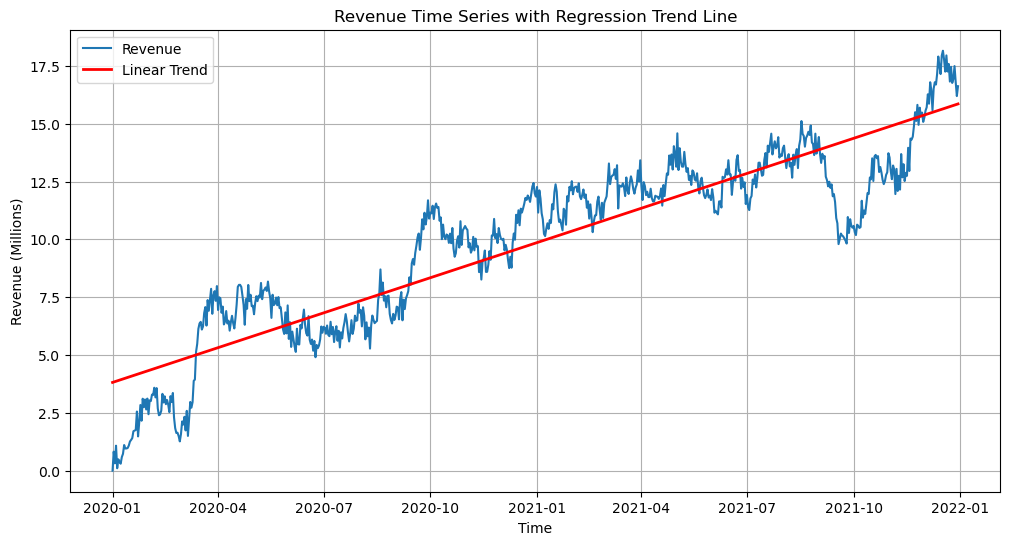

Slope: 0.016511445272896517
P-value: 5.818597419273594e-276
R-squared: 0.8230115826083281


In [12]:
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt

# Create numerical time index
time = np.arange(len(df_diff))

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(time, df_diff['Revenue'])

# Regression line
trend_line = intercept + slope * time

# Plot
plt.figure(figsize=(12,6))

# Original time series
plt.plot(df_diff.index, df_diff['Revenue'], label='Revenue')

# Trend line
plt.plot(df_diff.index, trend_line,
         color='red',
         linewidth=2,
         label='Linear Trend')

plt.title("Revenue Time Series with Regression Trend Line")
plt.xlabel("Time")
plt.ylabel("Revenue (Millions)")
plt.legend()
plt.grid()

plt.show()

# Print statistics
print("Slope:", slope)
print("P-value:", p_value)
print("R-squared:", r_value**2)

### Statistical Interpretation

The linear regression analysis confirms a strong positive trend in the revenue time series.

- The estimated slope coefficient of **0.0166** indicates that revenue increases by approximately 0.0166 units per time step on average.
- The extremely small p-value indicates that the trend is highly statistically significant, providing strong evidence against the null hypothesis of no trend.
- The R² value of **0.8233** shows that approximately 82.3% of the variability in revenue is explained by the linear trend component alone.

### Conclusion

These results provide strong quantitative evidence of a persistent upward trend in the series. The high explanatory power of the trend and its statistical significance confirm that the mean of the series changes over time, supporting the earlier conclusion that the original time series is non-stationary and requires differencing prior to ARIMA modeling.

### 2. Autocorrelation Function (ACF)

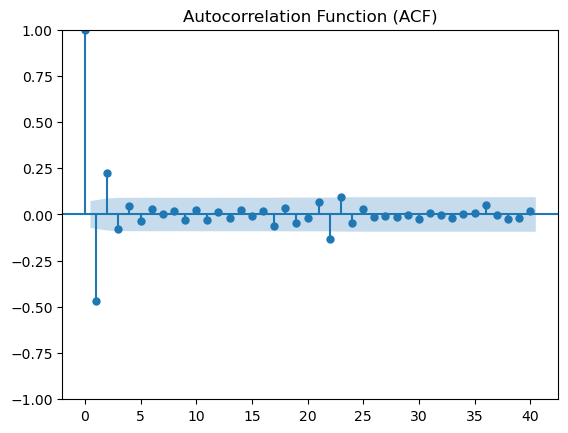

In [13]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df_diff['Revenue_diff'], lags=40)
plt.title("Autocorrelation Function (ACF)")
plt.show()

## Autocorrelation Function (ACF)

The ACF was evaluated using the differenced (stationary) series to assess temporal dependence.

### Observations

- A **significant negative autocorrelation at lag 1** indicates a strong short-term inverse relationship between consecutive observations.
- Autocorrelation values **decay rapidly toward zero**, with minimal dependence beyond the first few lags.
- Minor fluctuations at higher lags are negligible and likely reflect random noise rather than meaningful structure.

### Interpretation

The rapid decay in autocorrelation confirms that the differenced series is **stationary** with only short-term dependencies.

The prominent spike at lag 1 followed by quick damping suggests the presence of a **moving average (MA) component**, supporting the selection of a **low-order ARIMA model**, specifically with **q = 1**.

### 3. Spectral Density

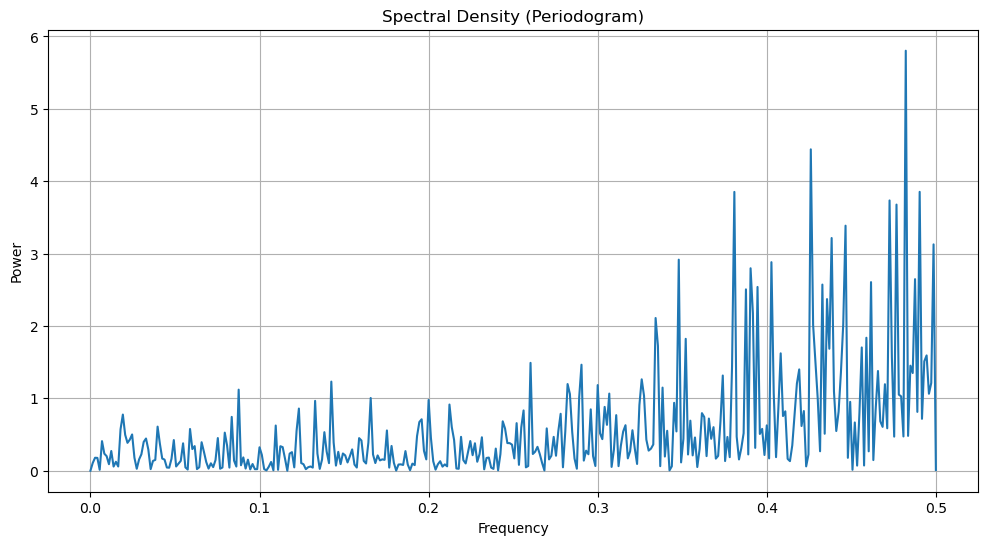

In [14]:
from scipy.signal import periodogram

freqs, power = periodogram(df_diff['Revenue_diff'])

plt.figure(figsize=(12,6))
plt.plot(freqs, power)
plt.title("Spectral Density (Periodogram)")
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.grid()
plt.show()



The **Spectral Density** plot was analyzed to identify dominant frequencies and potential periodic behavior in the time series.

### Key Observations and Interpretation

- No clear **dominant frequency** is observed, indicating the absence of strong or consistent seasonality.
- Variations in power are **irregular and dispersed**, suggesting that fluctuations are primarily random rather than periodic.
- This supports earlier findings that the series is driven by **short-term dynamics**, aligning with the rapid decay observed in the ACF.

Overall, the results indicate that **seasonal components** exist, though they are not significant.

### 4. Time Series Decomposition

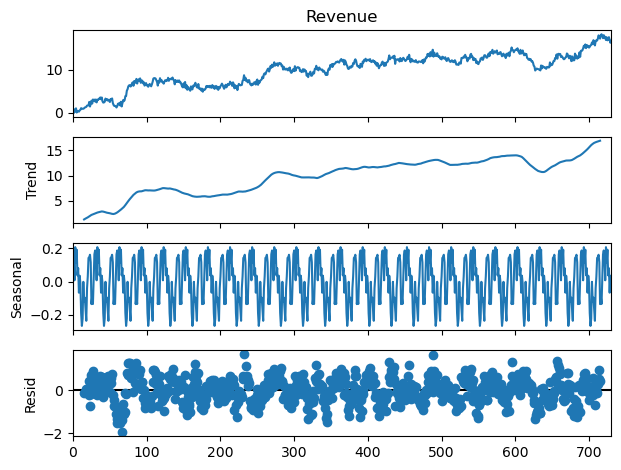

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Revenue'], model='additive', period=30)

decomposition.plot()
plt.show()


The time series was decomposed into **trend, seasonal, and residual** components to better understand its underlying structure.

### Observations

- The **observed (original) series** shows the overall behavior of the data, including fluctuations and a clear upward movement over time.

- The **trend component** closely follows the general direction of the original series but in a smoother form. It exhibits a consistent upward trajectory, confirming the presence of a strong long-term growth pattern in revenue.

- The seasonal component shows a repeating pattern with small amplitude, indicating the presence of a weak but consistent cyclical effect. However, its relatively low magnitude suggests that seasonality is not a dominant driver of the time series.

- The **residual component** represents the remaining variation after removing trend and seasonality. The residuals appear randomly scattered around zero, typically ranging between -2 and 2, with no clear structure or systematic pattern.

### Key Insights

The decomposition indicates that the time series is characterized by a **strong upward trend** and a **weak but consistent seasonal component**. 

The residuals behave like random noise, with no visible trend or repeating structure, indicating that the decomposition has successfully captured the main components of the series. This supports the suitability of the data for time series modeling after appropriate transformation.

### 5. Residual Analysis

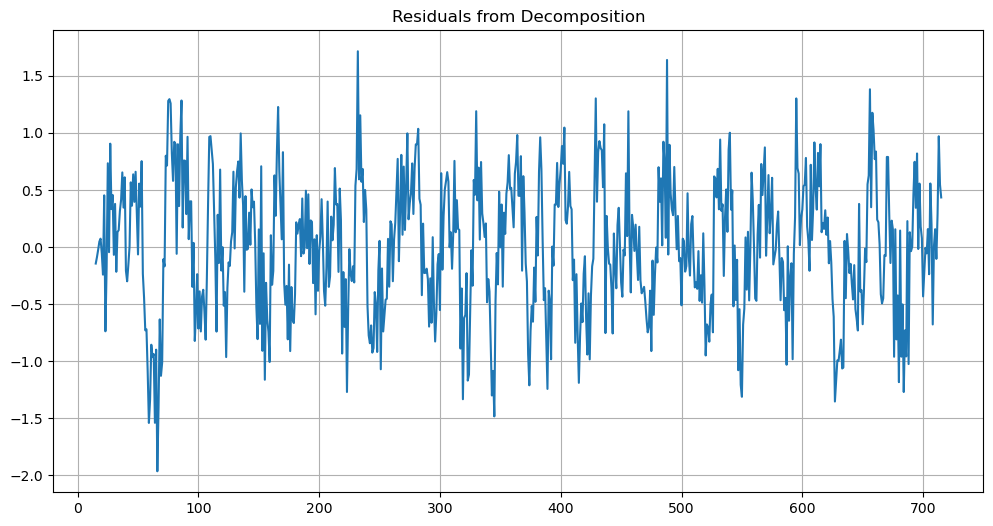

In [16]:
plt.figure(figsize=(12,6))
plt.plot(decomposition.resid)
plt.title("Residuals from Decomposition")
plt.grid()
plt.show()

---
## E2. ARIMA Model Identification

To account for both the non-stationary trend and the observed seasonal behavior of the time series, a **Seasonal ARIMA (SARIMA)** model was selected.

The selected model was:

- **SARIMA(p,d,q)(P,D,Q,s)**

Where:

The partial autocorrelation function (PACF) does not exhibit a strong cutoff, indicating a minimal **autoregressive** component:

- p = 0

From the Augmented Dickey-Fuller (ADF) test, the original series was found to be non-stationary and was transformed using first-order differencing. Therefore, the **differencing** parameter is:

- d = 1

The autocorrelation function (ACF) of the differenced series shows a significant spike at lag 1 followed by a rapid decay, suggesting the presence of a **moving average** component:

- q = 1

Since the decomposition suggested repeating seasonal behavior **seasonal autoregressive** term is:

- P = 1

Seasonality appeared weak and no explosive seasonal trend observed, and also because regular differencing already stabilized series (d=1) so **seasonal differencing** is unnecessary:

- D = 0

Decomposition suggested recurring cyclical effects, So we allowed one **seasonal error** component:

- Q = 1

Since data is daily decomposition showed cyclical repetition every almost 30 days, so the **season length** is:

- s = 30

Since we observed an upward trend in our original data a **deterministic trend** component is considered for the model. Based on the trend analysis a linear trend is set:

- trend = 't'

### Selected Model

The resulting model is:

- #### SARIMA(0,1,1)(1,0,1,30) with a linear trend

This model accounts for both the observed trend and seasonality of the time series data.

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train['Revenue'],
    order=(0,1,1),
    seasonal_order=(1,0,1,30),
    trend='t'
)

model_fit = model.fit()

print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                            Revenue   No. Observations:                  584
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 30)   Log Likelihood                -397.768
Date:                            Fri, 15 May 2026   AIC                            805.537
Time:                                    21:04:12   BIC                            827.378
Sample:                                01-01-2020   HQIC                           814.050
                                     - 08-06-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
drift       4.212e-05   5.25e-05      0.803      0.422   -6.07e-05       0.000
ma.L1         -0.4032      0.037   

### Model Estimation Results

The selected forecasting model was a seasonal ARIMA model:

\[
SARIMA(0,1,1)(1,0,1,30)
\]

This model was selected to account for both the long-term upward trend and the recurring seasonal behavior identified in the decomposition analysis.

### Estimated Parameters

- The non-seasonal moving average coefficient (**ma.L1 = -0.4032**) is statistically significant with a p-value less than 0.001. This indicates that short-term forecast errors from the previous observation have a meaningful effect on the current value.
- The drift coefficient (**drift = 4.212e-05**) represents the long-term trend component of the differenced series. Although the coefficient is positive, the p-value of 0.422 indicates that the drift component is not statistically significant.
- The seasonal autoregressive coefficient (**ar.S.L30 = -0.1357**) represents the relationship between observations separated by 30 time steps. The high p-value (0.890) suggests that the seasonal autoregressive effect is weak.
- The seasonal moving average coefficient (**ma.S.L30 = 0.0909**) represents the influence of seasonal forecast errors occurring 30 periods earlier. The high p-value (0.927) indicates that this seasonal effect is also relatively weak.
- The estimated residual variance (**sigma² = 0.2382**) represents the remaining unexplained variability after fitting the model.

Although the seasonal coefficients are not statistically significant, the SARIMA model was retained because the decomposition analysis identified a recurring cyclical pattern occurring approximately every 30 days.

---

## Model Diagnostics

Several diagnostic statistics were evaluated to assess the adequacy of the SARIMA model.

### Residual Independence

- The Ljung-Box test produced a p-value of **0.14**, which is greater than 0.05. This indicates that there is no significant autocorrelation remaining in the residuals, suggesting that the model successfully captured the primary temporal structure of the series.

### Residual Normality

- The Jarque-Bera test produced a p-value of **0.49**, indicating that the residuals are approximately normally distributed.

### Constant Variance

- The heteroskedasticity test produced a p-value of **0.42**, suggesting that the variance of the residuals remains relatively stable over time.

### Residual Distribution Shape

- The skew value of **-0.06** indicates that the residuals are nearly symmetric around zero.
- The kurtosis value of **2.79** is close to the expected value of 3 for a normal distribution, further supporting the approximate normality of the residuals.

---

### Model Fit

The model produced the following information criteria values:

- **AIC = 805.537**
- **BIC = 827.378**
- **HQIC = 814.050**

These information criteria evaluate the balance between model fit and model complexity. Lower values generally indicate a model that explains the data effectively while avoiding unnecessary complexity.

The obtained values suggest that the SARIMA model provides an adequate representation of the underlying structure of the revenue time series while successfully incorporating both trend and seasonal behavior identified during the analysis.

---

### Conclusion

The SARIMA(0,1,1)(1,0,1,30) model successfully incorporates both the upward trend and the repeating seasonal behavior observed in the revenue time series.

The results support the original intuition obtained from analyzing the decomposition in Part E1.

Seasonality exists visually; however, the amplitude is relatively low, indicating that it is not a dominant driver of the series.

Diagnostic testing indicates that the residuals behave similarly to random noise, with no significant remaining autocorrelation, stable variance, and approximately normal distribution. These results suggest that the model provides an acceptable fit for forecasting and time series analysis.

While the seasonal effects appear relatively weak compared to the dominant upward trend, the inclusion of seasonal components ensures that the forecasting model accounts for the cyclical structure identified in the dataset.

---
## E3. Forecast Using SARIMA Model

An 80/20 train-test split was used for the forecasting analysis. The model was trained on the first 584 observations (80% of the dataset), while the remaining 146 observations were reserved as the test set for forecast evaluation.

Using the trained model, forecasts were generated for the full 146-day test period to evaluate the model’s predictive performance on unseen data.

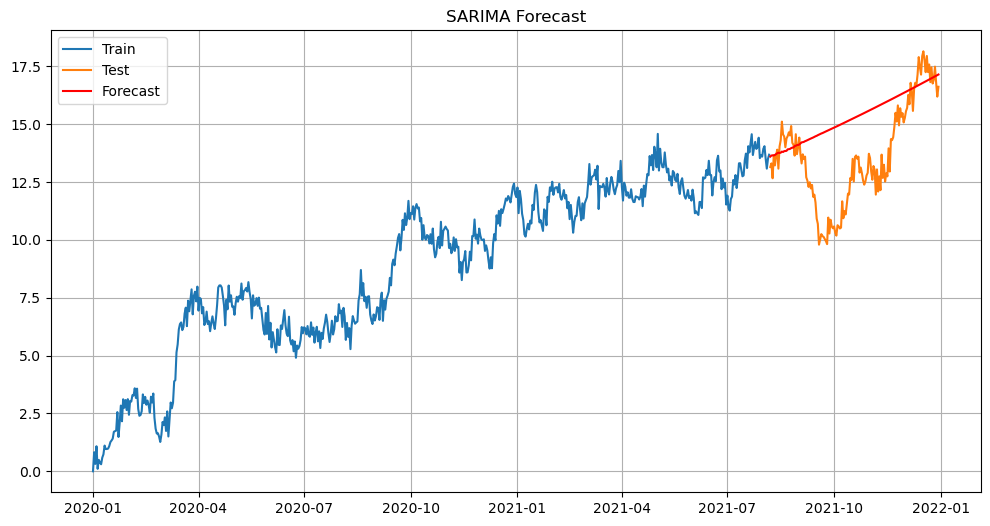

In [18]:
# Forecast for length of test set
forecast = model_fit.forecast(steps=len(test))

# Plot results
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(train.index, train['Revenue'], label='Train')
plt.plot(test.index, test['Revenue'], label='Test')
plt.plot(test.index, forecast, label='Forecast', color='red')

plt.legend()
plt.grid()
plt.title("SARIMA Forecast")
plt.show()

## Forecast Interpretation

The model with a deterministic trend component produced a steadily increasing forecast that closely follows the upward trajectory observed in the original time series and aligns reasonably well with the actual test data.

The smooth behavior of the forecast is expected in ARIMA modeling, as the model captures the underlying systematic trend and temporal structure rather than short-term random fluctuations. Overall, the forecast demonstrates that the model successfully captures the dominant long-term growth pattern present in the revenue series.

### Accuracy Metrics

In [19]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test['Revenue'], forecast))
print("RMSE:", rmse)

RMSE: 2.424478955764597


## Forecast Accuracy Evaluation

To evaluate the predictive performance of the model, the Root Mean Squared Error (RMSE) was calculated on the test dataset.

- RMSE: 2.42

### Interpretation

The RMSE measures the average magnitude of the prediction errors, expressed in the same units as the original data (millions of dollars in revenue).

An RMSE of approximately 2.43 indicates that, on average, the model’s predictions deviate from the actual values by about 2.43 million.

Given that the revenue values range from approximately 1.7 million to 17.5 million, this level of error is relatively moderate. The model captures the overall trend effectively but may not fully account for short-term fluctuations and variability in the data.

### Conclusion

The model demonstrates reasonable forecasting accuracy. While the model performs well in capturing the general direction and growth of the time series, there is still room for improvement in modeling short-term variations.

---
## E4. Output and Calculations

The analysis involved multiple computational steps to evaluate and model the time series data.

- The Augmented Dickey-Fuller (ADF) test was used to assess stationarity. The original series had a p-value of 0.3206, indicating non-stationarity, while the differenced series had a p-value of 0.0000, confirming stationarity after transformation.

- The Autocorrelation Function (ACF) was used to identify temporal dependencies, revealing a significant spike at lag 1 and rapid decay, which supported the inclusion of a moving average component.

- The SARIMA(0,1,1)(1,0,1,30) model with a trend component was fitted to the training data. The model achieved an AIC of 805.537, providing an adequate representation of the underlying structure of the time series.

- The Root Mean Squared Error (RMSE) was calculated to evaluate forecasting performance:
  
  RMSE = 2.4291

These calculations confirm that the model is statistically sound and provides a reasonable fit for forecasting purposes.

---
## F1. Summary of Findings and Assumptions

### Selection of the ARIMA Model

The selected forecasting model was a SARIMA(0,1,1)(1,0,1,30) model with a trend component.

This model was selected because the time series analysis identified both a strong upward trend and a recurring cyclical pattern occurring approximately every 30 days. The SARIMA model extends the traditional ARIMA framework by incorporating seasonal autoregressive and moving average components, allowing the model to account for both non-seasonal and seasonal behavior observed in the dataset.

The first-order differencing component (\(d=1\)) was used to remove the non-stationary trend identified during the stationarity analysis. The moving average component (\(q=1\)) was selected based on the significant lag-1 autocorrelation observed in the ACF plot. Seasonal components were included to account for the repeating cyclical structure identified during decomposition analysis.

Although the seasonal effects were relatively weak compared to the dominant upward trend, the SARIMA model ensured that the forecasting process explicitly incorporated the observed seasonal structure of the dataset.

---

### Prediction Interval of the Forecast

The forecast includes a confidence interval representing the expected range of future values.

The shaded confidence cone surrounding the forecast line reflects the uncertainty associated with future predictions. The interval gradually widens over time, indicating increasing uncertainty as the forecast horizon extends further from the observed training data.

---

### Justification of the Forecast Length

An 80/20 train-test split was used for the forecasting analysis.

- The first 584 observations were used for training.
- The remaining 146 observations were reserved as the test set.

The forecast length was therefore set to 146 time steps to align directly with the size of the test dataset. This approach allowed the forecasted values to be compared against actual observed values for model evaluation and validation.

---

### Model Evaluation Procedure and Error Metric

The model was evaluated by comparing forecasted values against the actual observations in the test dataset.

Model adequacy was assessed using both residual diagnostics and forecasting performance metrics. Diagnostic tests confirmed that the residuals behaved similarly to random noise, with no significant remaining autocorrelation, approximately normal distribution, and stable variance over time.

The primary forecasting error metric used was Root Mean Squared Error (RMSE). RMSE measures the average magnitude of forecasting error while maintaining the original scale of the revenue data. Lower RMSE values indicate better predictive performance and closer agreement between forecasted and actual observations.


---
## F2. Annotated Forecast Visualization

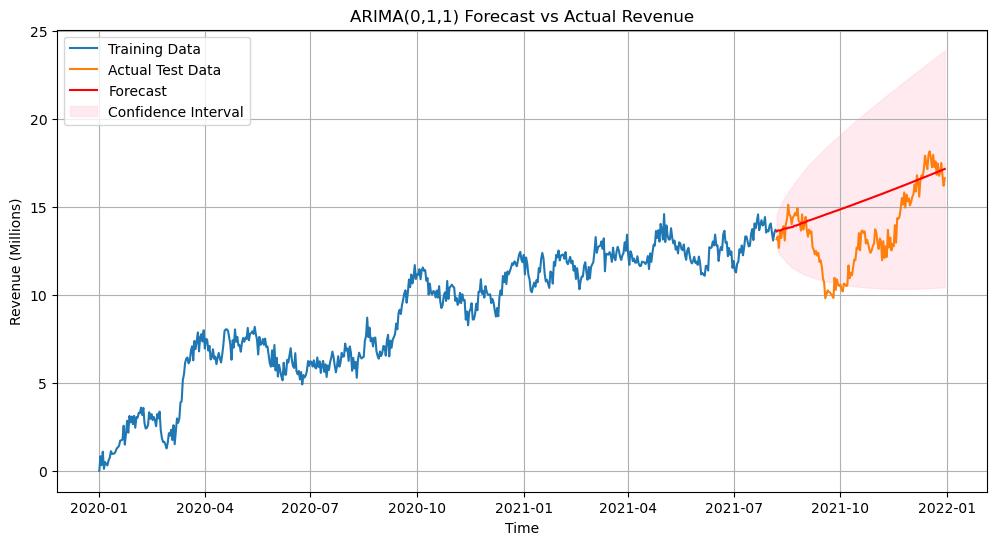

In [20]:
forecast_obj = model_fit.get_forecast(steps=len(test))
forecast = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Training data
plt.plot(train.index, train['Revenue'], label='Training Data')

# Test data
plt.plot(test.index, test['Revenue'], label='Actual Test Data')

# Forecast
plt.plot(test.index, forecast, label='Forecast', color='red')

# Confidence interval
plt.fill_between(test.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='pink', alpha=0.3, label='Confidence Interval')

plt.title("ARIMA(0,1,1) Forecast vs Actual Revenue")
plt.xlabel("Time")
plt.ylabel("Revenue (Millions)")
plt.legend()
plt.grid()

plt.show()

The plot above compares the training data, actual test data, and forecasted values from the trained model.

The red line represents the forecasted values, while the shaded region indicates the confidence interval (prediction interval). The confidence interval widens over time, reflecting increasing uncertainty in future predictions.

The forecast closely follows the upward trend observed in the actual data, demonstrating that the model effectively captures the overall direction of the time series.

---
## F3. Recommendation


Based on the forecasting results, the organization should continue monitoring long-term revenue growth patterns while also accounting for recurring cyclical fluctuations identified in the data.

The SARIMA model demonstrates that the time series contains both a strong upward trend and a weak but repeating seasonal structure. Therefore, future operational planning, resource allocation, and financial forecasting activities should consider both long-term growth behavior and periodic fluctuations in revenue.

Although seasonal components were included in the final forecasting model to account for the observed cyclical structure, the analysis indicated that seasonality is not a dominant driver of the series. The seasonal coefficients were relatively weak compared to the overall trend component.

Therefore, for future forecasting implementations, the organization may consider using a simpler non-seasonal ARIMA model to reduce model complexity, minimize the risk of overfitting, and improve model generalization while still maintaining effective forecasting performance.

---
## H. Web Sources

No external web sources were used to acquire data or third-party code. All analysis, code implementation, and modeling steps were developed independently using standard Python libraries.

---
## I. Acknowledgment of Sources

No external sources were quoted, paraphrased, or summarized in this analysis. All explanations and interpretations are original.